In [1]:
import torch
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [2]:
dataset=load_dataset("stanfordnlp/imdb")
print(dataset)
print("\nSample review :")
print("Text :",dataset['train'][0]['text'][:300])
print("Label :",dataset['train'][0]['label'],"(0=Negative,1=Positive)")
print(f"\nTotal training samples available : {len(dataset['train'])}")
print(f"Total test samples available     : {len(dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review :
Text : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
Label : 0 (0=Negative,1=Positive)

Total training samples available : 25000
Total test samples available     : 25000


In [3]:
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")
sample="I love this movie !"
tokens=tokenizer(sample,return_tensors="pt")
print("Input IDs :",tokens['input_ids'])
print("Attention Mask :",tokens['attention_mask'])
print("Tokens :",tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))

Input IDs : tensor([[ 101, 1045, 2293, 2023, 3185,  999,  102]])
Attention Mask : tensor([[1, 1, 1, 1, 1, 1, 1]])
Tokens : ['[CLS]', 'i', 'love', 'this', 'movie', '!', '[SEP]']


In [4]:
small_train=dataset['train'].shuffle(seed=42).select(range(8000))
small_test=dataset['test'].shuffle(seed=42).select(range(8000))

train_labels = small_train['label']
print(f"Train size : {len(small_train)}")
print(f"  Positive : {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)")
print(f"  Negative : {len(train_labels)-sum(train_labels)} ({(1-sum(train_labels)/len(train_labels))*100:.1f}%)")
print(f"\nTest size  : {len(small_test)}")

Train size : 8000
  Positive : 4012 (50.1%)
  Negative : 3988 (49.9%)

Test size  : 8000


In [5]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_test  = small_test.map(tokenize_function,  batched=True)

tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])

print("Tokenized train size:", len(tokenized_train))
print("Tokenized test size :", len(tokenized_test))

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenized train size: 8000
Tokenized test size : 8000


In [6]:
model=AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
print("Model loaded !")
print(f"Number of parameters :{model.num_parameters():,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded !
Number of parameters :66,955,010


In [7]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = np.argmax(pred.predictions,axis=1)

  acc=accuracy_score(labels,preds)
  return{"accuracy":acc}

In [8]:
use_fp16 = torch.cuda.is_available()

In [9]:
training_args = TrainingArguments(
    output_dir="./sentiment_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=150,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    report_to="none",
    fp16=use_fp16,
)

print("Training arguments set!")
print(f"fp16 (mixed precision): {use_fp16}")

Training arguments set!
fp16 (mixed precision): True


In [10]:
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.382100,0.340463,0.850500
2,0.243600,0.363538,0.863250
3,0.121100,0.535733,0.864500


TrainOutput(global_step=1500, training_loss=0.2665626665751139, metrics={'train_runtime': 184.1359, 'train_samples_per_second': 130.339, 'train_steps_per_second': 8.146, 'total_flos': 794804391936000.0, 'train_loss': 0.2665626665751139, 'epoch': 3.0})

In [12]:
results = trainer.evaluate()
print(f"Accuracy : {results['eval_accuracy']*100:.2f}%")
print(f"Loss     : {results['eval_loss']:.4f}")
print()

predictions = trainer.predict(tokenized_test)
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

Accuracy : 86.45%
Loss     : 0.5357

              precision    recall  f1-score   support

    Negative       0.89      0.84      0.86      3988
    Positive       0.84      0.89      0.87      4012

    accuracy                           0.86      8000
   macro avg       0.87      0.86      0.86      8000
weighted avg       0.87      0.86      0.86      8000



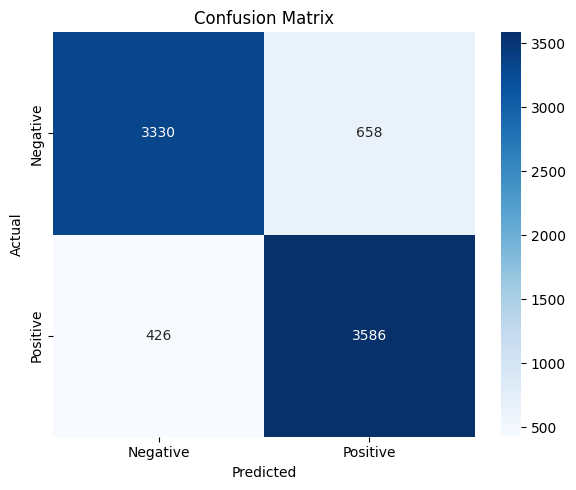

Confusion matrix saved.


In [13]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./sentiment_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

In [14]:
from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

tests = [
    "This movie was absolutely amazing!",
    "Terrible waste of time, worst movie ever.",
    "It was okay, nothing special.",
    "I loved every single moment of this film!",
    "Boring and predictable, fell asleep halfway through.",
    "The acting was brilliant but the plot was confusing."
]

label_map = {"LABEL_0": "NEGATIVE", "LABEL_1": "POSITIVE"}

print(f"{'Text':<55} {'Label':<10} {'Score'}")
print("-" * 75)
for text in tests:
    result = sentiment(text)[0]
    label  = label_map.get(result['label'], result['label'])
    print(f"{text:<55} {label:<10} {result['score']:.3f}")

Text                                                    Label      Score
---------------------------------------------------------------------------
This movie was absolutely amazing!                      POSITIVE   0.997
Terrible waste of time, worst movie ever.               NEGATIVE   0.997
It was okay, nothing special.                           NEGATIVE   0.985
I loved every single moment of this film!               POSITIVE   0.997
Boring and predictable, fell asleep halfway through.    NEGATIVE   0.996
The acting was brilliant but the plot was confusing.    NEGATIVE   0.993


In [15]:
model.save_pretrained("./my_sentiment_model")
tokenizer.save_pretrained("./my_sentiment_model")
print("Model and tokenizer saved to ./my_sentiment_model")

Model and tokenizer saved to ./my_sentiment_model


In [19]:
import json
from google.colab import files

with open('/content/sentiment_ananlysis.ipynb', 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    nb['metadata']['widgets'] = {
        "application/vnd.jupyter.widget-state+json": {
            "state": {},
            "version_major": 2,
            "version_minor": 0
        }
    }

with open('/content/sentiment_ananlysis.ipynb', 'w') as f:
    json.dump(nb, f, indent=2)

files.download('/content/sentiment_ananlysis.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from google.colab import files
files.upload()

Saving sentiment_ananlysis.ipynb to sentiment_ananlysis.ipynb


{'sentiment_ananlysis.ipynb': b'{\n  "nbformat": 4,\n  "nbformat_minor": 0,\n  "metadata": {\n    "colab": {\n      "provenance": [],\n      "gpuType": "T4"\n    },\n    "kernelspec": {\n      "name": "python3",\n      "display_name": "Python 3"\n    },\n    "language_info": {\n      "name": "python"\n    },\n    "accelerator": "GPU",\n    "widgets": {\n      "application/vnd.jupyter.widget-state+json": {\n        "62e99ec937b14e60a824aed5b56efe30": {\n          "model_module": "@jupyter-widgets/controls",\n          "model_name": "HBoxModel",\n          "model_module_version": "1.5.0",\n          "state": {\n            "_dom_classes": [],\n            "_model_module": "@jupyter-widgets/controls",\n            "_model_module_version": "1.5.0",\n            "_model_name": "HBoxModel",\n            "_view_count": null,\n            "_view_module": "@jupyter-widgets/controls",\n            "_view_module_version": "1.5.0",\n            "_view_name": "HBoxView",\n            "box_style": "

In [12]:
!pip install numpy==1.26.4 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 56.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.25.0 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.25.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0,

In [23]:
import json
from google.colab import files

with open('/content/sentiment_ananlysis.ipynb', 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('/content/sentiment_ananlysis.ipynb', 'w') as f:
    json.dump(nb, f, indent=2)

files.download('/content/sentiment_ananlysis.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>